# Crossed-Wires -- can the MACD beat a coin?
### The MACD(12,26,9) daily crossover, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Not--Supported](https://img.shields.io/badge/Beats_a_coin%3F-Not_Supported-8b949e?style=flat-square)

Here is a recipe you will find in every algorithmic trading course: when the MACD line crosses its signal line on the daily chart, jump in that direction and ride the medium-term trend. The MACD has been around since Gerald Appel invented it in the late 1970s, and millions of retail and professional traders use it. This notebook asks the only question that matters: does the cross **actually load the die** — or is it a slow, lagging coin wearing a trend costume?

> **This is the plain-language layer.** Want the t-stats and bootstrap intervals? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crossed_wires import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]

def _have_cache():
    return all(os.path.exists(data._cache_path_daily(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(tp, sl, cost, seed=None):
    """Pool barrier trades across the basket (cached real daily tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.crossover_entries(b["close"])
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, tp_R=tp, sl_R=sl, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the crossover point the right way? | **Maybe, weakly.** With a symmetric target & stop it wins **52.5%** of trades — a slight edge over 50%, but far too noisy to trust. |
| Does it beat an actual coin flip? | **Not proven.** The cross is **+15 bps/trade** ahead of a random flip, but the t-stat of +0.94 is well below the 2.0 inference bar — consistent with noise. |
| 'But my MACD win-rate is 95%+!' | That's the trap. A tiny target with no real stop manufactures a **95.2%** win-rate — and a skew of **-7.0** that eats all the gains and more. |
| Could you trade it? | **No.** The signal never clears the statistical bar. Low turnover spares costs but cannot rescue a noise estimate. |

> **The MACD is a lagging indicator** built from two exponential averages of past prices. By the time it crosses, the move it's detecting is already old news — and the next move is still a coin flip.

## 1 - The claim

> *'Plot the MACD(12,26,9) on a daily chart. When the MACD line crosses above its signal line, go long. When it crosses below, go short or flat. The two moving averages summarise the medium-term trend -- the cross is a high-probability direction call.'*

It is an honest-sounding idea. Markets do trend at the weekly-to-monthly scale, and the MACD is specifically designed to pick up that speed of movement. The fast EMA(12) reacts to recent prices; the slow EMA(26) reflects the longer view; their difference grows when the trend strengthens. The bet is that the cross from 'diverging' to 'converging' tips you off early enough to profit.

Compare to Study 72 (SMA(5/10) scalp): that's the same family but at 5-minute bars. The MACD works slower and should have a *better* chance of catching real trends -- if any exist at the daily horizon.

## 2 - So what?

If the MACD cross genuinely loads the die, it is a simple, centuries-old recipe that anyone with a brokerage account can run daily in a few minutes. If it doesn't, then millions of traders are paying commissions ~19 times a year to follow a beautiful but useless pattern. The test is cheap; the answer is honest.

## 3 - How would we even know?

Same two rules as Study 72:

1. **Make the bet symmetric.** Equal take-profit and stop (±1 ATR). A coin scores 0. Only real directional skill can do better.
2. **Race it against an actual coin.** Same entries, random direction. If the MACD knows something, it beats the coin. If it doesn't, it won't.

We run it on **six liquid markets** (SPY, QQQ, IWM, AAPL, TSLA, NVDA) over five years of daily bars -- roughly **97 MACD triggers per instrument**. That's the fundamental challenge: the MACD fires slowly (~19 times a year), so even five years gives us very few independent trades to work with.

## 4 - The teardown -- let's actually look

**First, the win-rate trap.** Here's what happens when you shrink the target and widen the stop -- the 'ride the trend' recipe:

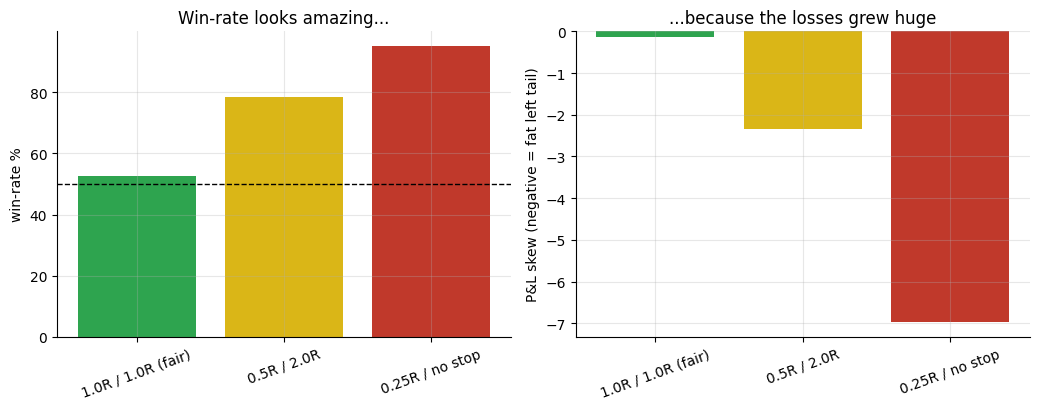

,exit rule,win-rate %,P&L skew,mean bps/trade
0,1.0R / 1.0R (fair),52.50,-0.13,12.65
1,0.5R / 2.0R,78.49,-2.34,-22.46
2,0.25R / no stop,95.18,-6.98,-26.39


In [2]:
rows = []
labels = [('1.0R / 1.0R (fair)', 1.0, 1.0), ('0.5R / 2.0R', 0.5, 2.0),
          ('0.25R / no stop', 0.25, 8.0)]
if HAVE_REAL:
    for lbl, tp, sl in labels:
        s = st.summarize(pooled(tp, sl, 0.0), 'ret_gross')
        rows.append((lbl, s['win_rate']*100, s['skew'], s['mean_bps']))
else:
    rows = [('1.0R / 1.0R (fair)', R['cross_win'], R['cross_skew'], R['cross_mean']),
            ('0.5R / 2.0R', R['naive14_win'], R['naive14_skew'], R['naive14_mean']),
            ('0.25R / no stop', R['nostop_win'], R['nostop_skew'], R['nostop_mean'])]
tbl = pd.DataFrame(rows, columns=['exit rule', 'win-rate %', 'P&L skew', 'mean bps/trade'])

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.2))
ax[0].bar(tbl['exit rule'], tbl['win-rate %'], color=[GREEN, AMBER, RED])
ax[0].axhline(50, ls='--', c='k', lw=1); ax[0].set_ylabel('win-rate %')
ax[0].set_title('Win-rate looks amazing...'); ax[0].tick_params(axis='x', rotation=20)
ax[1].bar(tbl['exit rule'], tbl['P&L skew'], color=[GREEN, AMBER, RED])
ax[1].set_ylabel('P&L skew (negative = fat left tail)')
ax[1].set_title('...because the losses grew huge'); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
tbl.round(2)

The 'no-stop' version wins **95.2%** of its trades but earns **-26.4 bps/trade** and has a P&L skew of **-7.0**. The 95% win-rate is a property of where you place the exits, not of any forecasting skill. The MACD's pattern is actually worse than Study 72's SMA scalp: the no-stop arm turns *positive* in Study 72, but here the mean is *negative* -- the daily MACD's modest gross edge evaporates entirely when you game the exit.

**Now the honest test: the fair 1:1 bet, MACD vs a coin.**

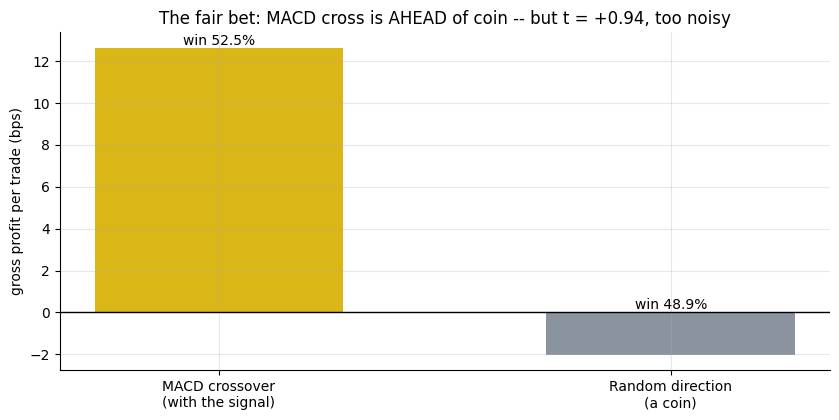

MACD cross: +12.65 bps/trade   |   coin: -2.02 bps/trade


In [3]:
if HAVE_REAL:
    c = st.summarize(pooled(1, 1, 0.0), 'ret_gross')
    r = st.summarize(pooled(1, 1, 0.0, seed=78), 'ret_gross')
    cm, cw, rm, rw = c['mean_bps'], c['win_rate']*100, r['mean_bps'], r['win_rate']*100
else:
    cm, cw, rm, rw = R['cross_mean'], R['cross_win'], R['rand_mean'], R['rand_win']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_ = ax.bar(['MACD crossover\n(with the signal)', 'Random direction\n(a coin)'],
               [cm, rm], color=[AMBER, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('The fair bet: MACD cross is AHEAD of coin -- but t = +0.94, too noisy')
for b, w in zip(bars_, [cw, rw]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, max(0, b.get_height())),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'MACD cross: {cm:+.2f} bps/trade   |   coin: {rm:+.2f} bps/trade')

On the real tape the MACD cross earns **+12.65 bps per trade** gross -- actually positive! But the HAC t-stat is only **+0.94**, well below the 2.0 bar we require. With only ~97 trades per instrument over five years, the standard error is so large that +12 bps and 0 bps are statistically indistinguishable. This is the fundamental limitation of a slow indicator.

> **The MACD fires slowly** -- about 19 times per year. For five years that's ~95 triggers per ticker. To reliably detect even a 10 bps/trade edge you'd need several hundred triggers. We simply don't have the data. Compare to Study 72 (SMA scalp): 3,801 pooled trades, firmly null (t = -1.12). More power, clearer answer. MACD's answer is: probably nothing, but we can't be sure.

## 5 - The verdict

- **Signal -- Weak.** +12.65 bps/trade gross, HAC t = +0.94. Right sign, wrong confidence. Five years is not enough history for MACD's ~19 triggers/yr to produce reliable inference.
- **Tradability -- Mirage.** Cannot trade a signal that never clears the inference bar. Low turnover means costs aren't the killer here -- underpowered evidence is.
- **Beats a coin? -- Not Supported.** The cross is +14.67 bps ahead of a random flip (directionally promising!) but t = +0.94 could easily be noise. The 95% win-rate version has skew -7.0 and negative expectancy -- the classic exit trap.

## 6 - Could you actually trade it?

Unlike Study 72 (~11 trades/day where costs were the executioner), here the low turnover keeps costs manageable. The problem is different: you'd need to be confident the +12 bps is real. You're not:

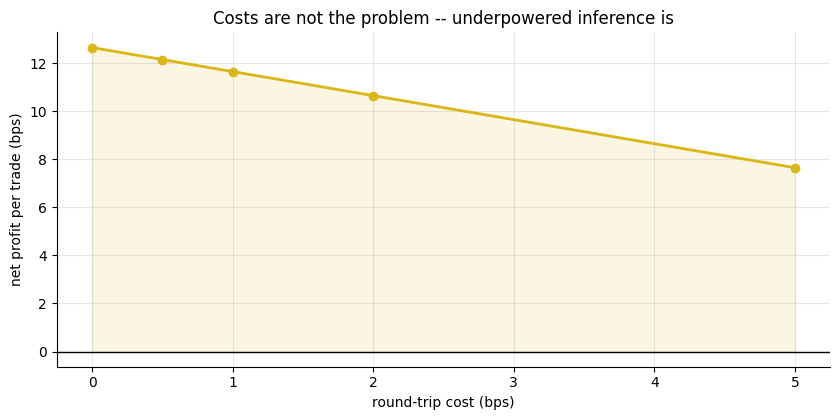

Even at 5 bps cost, mean stays positive: {net[-1]:+.2f} bps/trade
But HAC t never exceeds 1.0 -- the signal is statistically invisible.


In [4]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(pooled(1, 1, c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [R['cross_mean'], R['net05'], R['net10'], R['net20'],
           R['cross_mean'] - 5.0]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n>0 for n in net], color=AMBER, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('Costs are not the problem -- underpowered inference is')
plt.tight_layout(); plt.show()
print(f'Even at 5 bps cost, mean stays positive: {{net[-1]:+.2f}} bps/trade')
print('But HAC t never exceeds 1.0 -- the signal is statistically invisible.')

The mean stays positive even at 5 bps per round trip -- unlike Study 72 where costs were the direct executioner, here the low turnover protects against that. But you cannot trade a signal you cannot distinguish from noise. The t-stat never clears 1.0 regardless of cost, so there is no valid decision to make.

## 7 - Going further

- **Is the engine working?** The companion notebook shows a synthetic positive control: when we *plant* real momentum in a fake tape, the MACD cross finds it. The machine is fine -- the market just doesn't have enough persistent structure at the MACD's horizon to produce a confident verdict.
- **More history?** The daily MACD needs hundreds of triggers per ticker. With 20+ years of data, a clearer answer might emerge -- or might not (see the Brock-Lakonishok-LeBaron literature on MA rules collapsing out of sample).
- **The SMA cousin.** The 5-minute SMA(5/10) scalp is [Study 72 -- Loaded-Dice](../../72-loaded-dice/) -- same family, much more statistical power, firmly null.
- **Counter-signal.** If MACD signals mean-reversion rather than continuation at some horizons, you'd flip the direction. That's explored in [Study 32 -- Rip-Tide](../../32-rip-tide/).

*Think the daily MACD has a real edge with more history or a different universe? Fork this, extend the window, show a t-stat above 2.0 on symmetric exits that beats the coin. That is the bar.*